In [1]:
import numpy as np
import pandas as pd
import scipy.cluster.hierarchy as sch
import scipy.spatial.distance as ssd
import cvxpy as cp
import matplotlib.pyplot as plt
import yfinance as yf
import warnings

warnings.filterwarnings("ignore")

In [2]:
# ==========================================
# 1. Asset Universe Definition
# ==========================================
# 30 Liquid Indian Equities (Replaced TATAMOTORS.NS with HINDUNILVR.NS)
equities = [
    'RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'ICICIBANK.NS', 'BHARTIARTL.NS',
    'INFY.NS', 'ITC.NS', 'SBIN.NS', 'LT.NS', 'BAJFINANCE.NS',
    'HCLTECH.NS', 'MARUTI.NS', 'SUNPHARMA.NS', 'HINDUNILVR.NS', 'KOTAKBANK.NS',
    'M&M.NS', 'AXISBANK.NS', 'NTPC.NS', 'TITAN.NS', 'ASIANPAINT.NS',
    'ULTRACEMCO.NS', 'POWERGRID.NS', 'WIPRO.NS', 'NESTLEIND.NS', 'JSWSTEEL.NS',
    'TATASTEEL.NS', 'GRASIM.NS', 'TECHM.NS', 'ADANIENT.NS', 'HINDALCO.NS'
]

# 4 Liquid Forex Pairs (vs INR)
forex = ['INR=X', 'EURINR=X', 'GBPINR=X', 'JPYINR=X']

# Indian Government Bond ETFs (Replacing defunct yield indices)
# LIQUIDBEES.NS: Short-Duration Proxy
bonds = ['LIQUIDBEES.NS']

all_tickers = equities + forex + bonds

In [3]:
# ==========================================
# 2. Robust Data Fetching & Processing Engine
# ==========================================
def fetch_and_process_data(start_date, end_date):
    """Fetches closing prices and calculates daily returns across asset classes."""
    print(f"Fetching data from {start_date} to {end_date}...")

    # Download data silently
    data = yf.download(all_tickers, start=start_date, end=end_date, progress=False)

    # Handle yfinance multi-index column changes in newer versions
    if isinstance(data.columns, pd.MultiIndex):
        data = data['Close']
    else:
        # Fallback if 'Close' isn't a top-level key but exists in columns
        data = data[[col for col in data.columns if 'Close' in col]]
        data.columns = [col.replace('Close', '').strip() for col in data.columns]

    # ffill() handles missing daily data (holidays).
    # bfill() ensures ETFs launched slightly after 2015 don't trigger NaN drops.
    data = data.ffill().bfill()

    returns = pd.DataFrame(index=data.index)

    # Process all assets identically since bond ETFs represent price, not yield
    for ticker in all_tickers:
        if ticker in data.columns:
            returns[ticker] = data[ticker].pct_change()

    # Drop the first row (NaN due to pct_change)
    return returns.dropna()

# Train Period: Jan 2015 - Dec 2022
train_returns = fetch_and_process_data('2015-01-01', '2022-12-31')

# Test Period: Jan 2024 - Dec 2025
test_returns = fetch_and_process_data('2024-01-01', '2025-12-31')

# Align columns to ensure consistency (in case a ticker failed entirely)
valid_tickers = train_returns.columns.intersection(test_returns.columns)
train_returns = train_returns[valid_tickers]
test_returns = test_returns[valid_tickers]

cov_matrix = train_returns.cov()
corr_matrix = train_returns.corr()

Fetching data from 2015-01-01 to 2022-12-31...
Fetching data from 2024-01-01 to 2025-12-31...


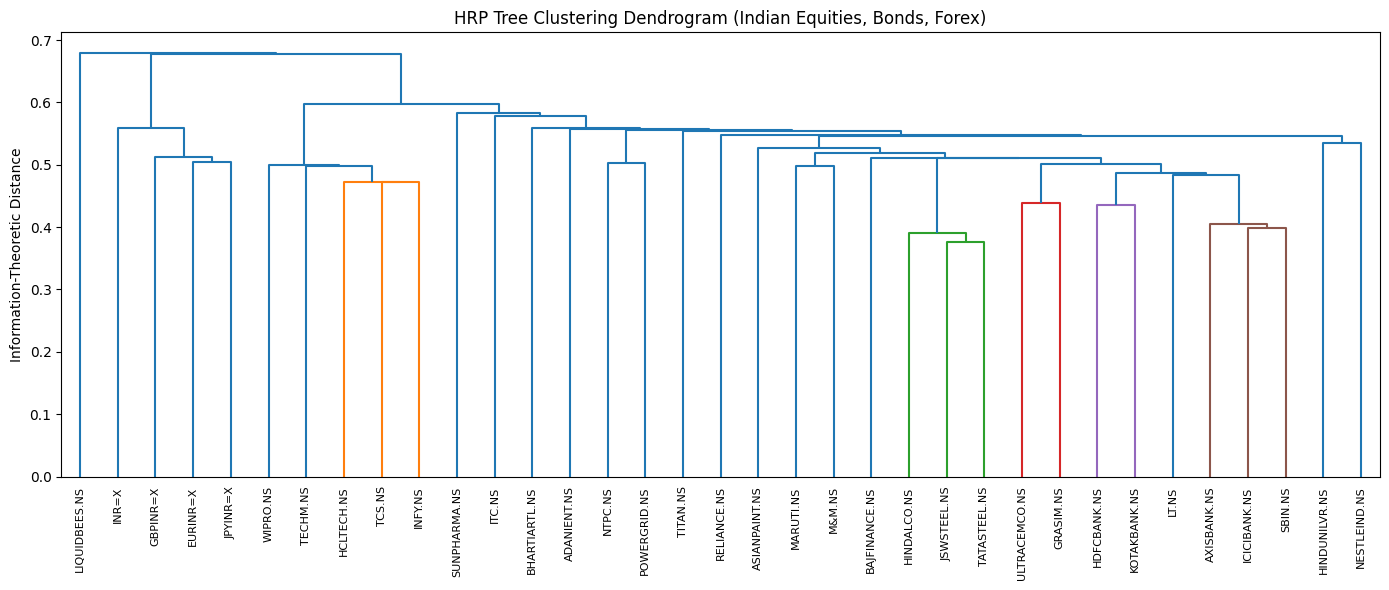

In [4]:
# ==========================================
# 3. HRP Algorithm Components
# ==========================================
# Step 1: Distance Metric Conversion
dist_matrix = np.sqrt(np.clip(0.5 * (1 - corr_matrix), 0, 1))
condensed_dist = ssd.squareform(dist_matrix, checks=False)

# Step 2: Tree Clustering
linkage_matrix = sch.linkage(condensed_dist, method='single')

# Plot Dendrogram
plt.figure(figsize=(14, 6))
sch.dendrogram(linkage_matrix, labels=corr_matrix.columns, leaf_rotation=90)
plt.title("HRP Tree Clustering Dendrogram (Indian Equities, Bonds, Forex)")
plt.ylabel("Information-Theoretic Distance")
plt.tight_layout()
plt.show()

# Step 3: Quasi-Diagonalization
sort_ix = sch.leaves_list(linkage_matrix)
sorted_tickers = corr_matrix.columns[sort_ix].tolist()

# Step 4: Recursive Bisection
def get_ivp(cov_):
    ivp = 1.0 / np.diag(cov_)
    ivp /= ivp.sum()
    return ivp

def get_cluster_var(cov_, c_items):
    cov_slice = cov_.loc[c_items, c_items]
    w_ = get_ivp(cov_slice)
    c_var = np.dot(w_.T, np.dot(cov_slice, w_))
    return c_var

def get_rec_bipart(cov_, sort_ix):
    w = pd.Series(1.0, index=sort_ix)
    c_items = [sort_ix]

    while len(c_items) > 0:
        c_items = [i[j:k] for i in c_items
                   for j, k in ((0, len(i) // 2), (len(i) // 2, len(i))) if len(i) > 1]

        for i in range(0, len(c_items), 2):
            c_items0 = c_items[i]
            c_items1 = c_items[i+1]

            c_var0 = get_cluster_var(cov_, c_items0)
            c_var1 = get_cluster_var(cov_, c_items1)

            alpha = 1 - c_var0 / (c_var0 + c_var1)

            w[c_items0] *= alpha
            w[c_items1] *= 1 - alpha

    return w

hrp_weights = get_rec_bipart(cov_matrix, sorted_tickers)

In [5]:
# ==========================================
# 4. Benchmark: Markowitz MVO (QP)
# ==========================================
n = len(valid_tickers)
w_mv = cp.Variable(n)
risk = cp.quad_form(w_mv, cov_matrix.values)
constraints = [cp.sum(w_mv) == 1, w_mv >= 0]
prob = cp.Problem(cp.Minimize(risk), constraints)
prob.solve(solver=cp.SCS) # Enforced robust solver

mv_weights = pd.Series(w_mv.value, index=valid_tickers)

# Clean up MVO weights (set near-zero values to 0)
mv_weights[mv_weights < 1e-4] = 0.0
mv_weights /= mv_weights.sum()


--- Out-of-Sample Volatility (2024-2025) ---
MVO MinVar Volatility : 1.91%
HRP Volatility        : 1.13%

--- Asset Allocation Weights ---
              HRP Weight MVO Weight
LIQUIDBEES.NS     94.38%     55.90%
INR=X              2.52%     24.53%
JPYINR=X           0.73%      3.52%
EURINR=X           0.70%      5.22%
GBPINR=X           0.64%      3.99%
WIPRO.NS           0.14%      0.40%
HCLTECH.NS         0.08%      0.00%
ITC.NS             0.07%      0.90%
TCS.NS             0.06%      0.86%
TECHM.NS           0.06%      0.00%
NTPC.NS            0.05%      0.00%
POWERGRID.NS       0.05%      0.99%
INFY.NS            0.05%      0.02%
SUNPHARMA.NS       0.05%      0.00%
BHARTIARTL.NS      0.05%      0.36%
TITAN.NS           0.03%      0.01%
HDFCBANK.NS        0.03%      0.74%
HINDUNILVR.NS      0.03%      0.63%
NESTLEIND.NS       0.03%      0.71%
ASIANPAINT.NS      0.03%      0.58%
RELIANCE.NS        0.02%      0.26%
KOTAKBANK.NS       0.02%      0.00%
LT.NS              0.02%      0.

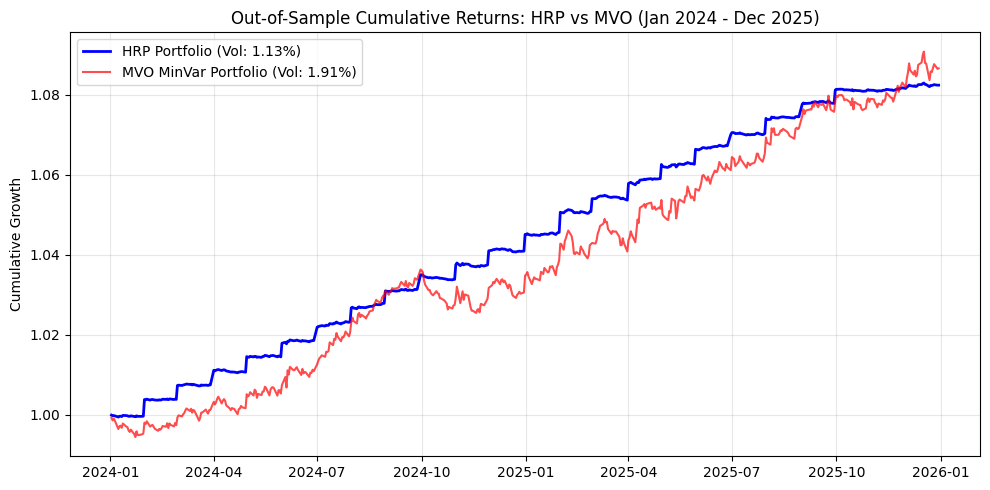

In [6]:
# ==========================================
# 5. Out-of-Sample Performance (2024 - 2025)
# ==========================================
hrp_weights = hrp_weights[valid_tickers]
mv_weights = mv_weights[valid_tickers]

# Calculate daily portfolio returns out-of-sample
hrp_oos_returns = test_returns.dot(hrp_weights)
mv_oos_returns = test_returns.dot(mv_weights)

# Annualized Volatility
hrp_vol = hrp_oos_returns.std() * np.sqrt(252)
mv_vol = mv_oos_returns.std() * np.sqrt(252)

# Cumulative Returns
hrp_cum = (1 + hrp_oos_returns).cumprod()
mv_cum = (1 + mv_oos_returns).cumprod()

print("\n--- Out-of-Sample Volatility (2024-2025) ---")
print(f"MVO MinVar Volatility : {mv_vol:.2%}")
print(f"HRP Volatility        : {hrp_vol:.2%}")

# Display Weights Comparison
print("\n--- Asset Allocation Weights ---")
weights_df = pd.DataFrame({'HRP Weight': hrp_weights, 'MVO Weight': mv_weights})
weights_df = weights_df.sort_values(by='HRP Weight', ascending=False)
print(weights_df.applymap(lambda x: f"{x:.2%}"))

# Plot Out-of-Sample Cumulative Returns
plt.figure(figsize=(10, 5))
plt.plot(hrp_cum.index, hrp_cum, label=f'HRP Portfolio (Vol: {hrp_vol:.2%})', color='blue', linewidth=2)
plt.plot(mv_cum.index, mv_cum, label=f'MVO MinVar Portfolio (Vol: {mv_vol:.2%})', color='red', alpha=0.7)
plt.title("Out-of-Sample Cumulative Returns: HRP vs MVO (Jan 2024 - Dec 2025)")
plt.ylabel("Cumulative Growth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()